495.04706480905355
0.0
[ 2.78933124e+01 -8.50376560e-01  2.08489471e-01 -1.27314173e+03
  1.27107968e+03  9.22012590e-01]


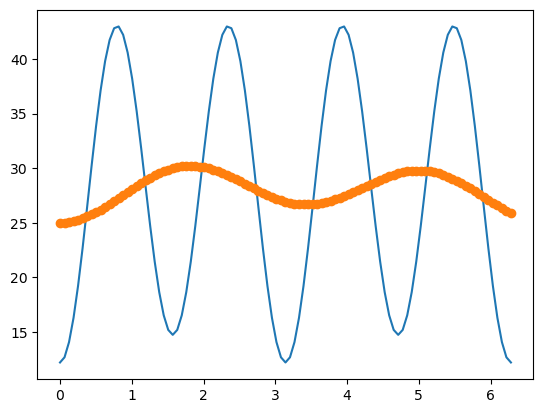

In [8]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from scipy.stats import chi2
import numpy as np
import pandas as pd

df3= pd.read_csv('freq_x_rot.csv', header = 0)

x_angle = df3['angle']
x_angle = x_angle*np.pi/180.
f_sx = df3['fre_sum']/1E3
f_dx = df3['freq_diff']/1E6
f_1Dx = df3['freq_1D']/1E6 #freq of |1> -> |0>
f_2Dx = df3['freq_2D']/1E6 #freq of |0> -> |-1>
# define the Fourier function

def fourier_func(x, a0, a1, b1,a2, b2, w):
    return a0 + a1*np.cos(w*x) + b1*np.sin(w*x) + a2*np.cos(2*w*x) + b2*np.cos(2*w*x)
x_data = x_angle
y_data = f_sx
# generate some dummy data
# x_data = np.linspace(0, 2*np.pi, 50)
# y_data = fourier_func(x_data, 1, 2, 3, 1) + np.random.normal(0, 0.2, len(x_data))

# fit the model to the data
params, _ = curve_fit(fourier_func, x_data, y_data)

# compute the chi-square value for the fit
residuals = y_data - fourier_func(x_data, *params)
chisq = np.sum(residuals**2 / y_data)

# print the chi-square value
print(chisq)

# compute the p-value for the fit
dof = len(x_data) - len(params)
p_value = 1 - chi2.cdf(chisq, dof)

# print the p-value
print(p_value)
print(params)

plt.plot(x_data, y_data)
plt.plot(x_data, fourier_func(x_data, *params), marker = 'o')